# Marketing Mix Modeling: Feature Engineering and Baseline Fit

## Scenario
A meal kit growth team wants to understand how weekly marketing channel spend
relates to revenue over time. Build the features for a time-aware marketing mix
model, fit a Ridge regression, and evaluate out-of-sample performance.

## Channels: search | social | influencer | email | affiliate
## Data: `mealkit_marketing_weekly.csv`  (104 weeks)


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path('Exercise_Data')
if not DATA_DIR.exists():
    DATA_DIR = Path('/content/drive/Othercomputers/My PC/Desktop/All_Work_Related/Udacity/Applied_Statistics_ND/Exercises/Udacity Exercises Redone/')

MMM_PATH = DATA_DIR / 'mealkit_marketing_weekly.csv'
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error

df = pd.read_csv(MMM_PATH)
df['date'] = pd.to_datetime(df['date'])
print(f"Weeks: {len(df)}  |  Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Revenue range: ${df['weekly_revenue'].min():,.0f} – ${df['weekly_revenue'].max():,.0f}")
print(f"Revenue mean: ${df['weekly_revenue'].mean():,.0f}")
df.head(3)

Weeks: 104  |  Date range: 2022-01-03 to 2023-12-25
Revenue range: $6,329 – $10,355
Revenue mean: $8,562


,week,date,spend_search,spend_social,spend_influencer,spend_email,spend_affiliate,weekly_revenue
0,1,2022-01-03,111,294,1029,274,120,7535.40
1,2,2022-01-10,606,363,858,165,250,7509.67
2,3,2022-01-17,481,499,1042,163,224,7023.48


## Step 1: Adstock Transformation

In [3]:
def apply_adstock(series, alpha=0.3):
    result = np.zeros(len(series))
    result[0] = series.iloc[0]
    for i in range(1, len(series)):
        result[i] = series.iloc[i] + alpha * result[i-1]
    return pd.Series(result, index=series.index)

spend_cols   = ['spend_search','spend_social','spend_influencer','spend_email','spend_affiliate']
adstock_cols = [c.replace('spend_','adstock_') for c in spend_cols]
for sc, ac in zip(spend_cols, adstock_cols):
    df[ac] = apply_adstock(df[sc], alpha=0.3)
print("Adstock columns created:", adstock_cols)

Adstock columns created: ['adstock_search', 'adstock_social', 'adstock_influencer', 'adstock_email', 'adstock_affiliate']


## Step 2: Time Controls

In [4]:
df['t']     = range(1, len(df) + 1)   # linear trend
df['sin52'] = np.sin(2 * np.pi * df['t'] / 52)   # annual seasonality (sine)
df['cos52'] = np.cos(2 * np.pi * df['t'] / 52)   # annual seasonality (cosine)
feat_cols = adstock_cols + ['t', 'sin52', 'cos52']
print("Time controls added. Total features:", len(feat_cols))

Time controls added. Total features: 8


## Step 3: Time-Based Train / Test Split (80/20)

In [5]:
split_idx = int(len(df) * 0.80)
train = df.iloc[:split_idx]
test  = df.iloc[split_idx:]
print(f"Train: {len(train)} weeks  |  Test: {len(test)} weeks")
print(f"Train ends: {train['date'].max().date()}  |  Test starts: {test['date'].min().date()}")

X_train = train[feat_cols].astype(float)
y_train = train['weekly_revenue'].astype(float)
X_test  = test[feat_cols].astype(float)
y_test  = test['weekly_revenue'].astype(float)

Train: 83 weeks  |  Test: 21 weeks
Train ends: 2023-07-31  |  Test starts: 2023-08-07


## Step 4: Fit Ridge Regression

In [6]:
model = Ridge(alpha=1.0)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
print(f"Test MAE: ${mae:,.0f}")
print(f"As % of mean revenue: {mae / df['weekly_revenue'].mean() * 100:.1f}%")

Test MAE: $240
As % of mean revenue: 2.8%


## Step 5: Actual vs Predicted Plot

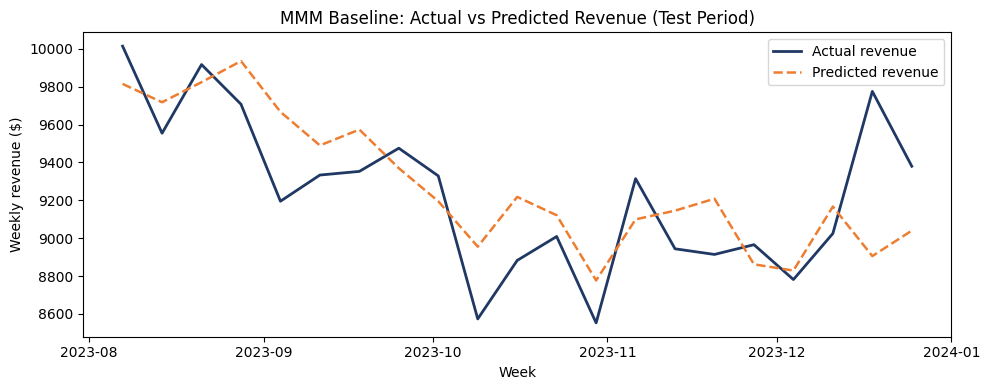

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(test['date'], y_test,  color='#1F3864', linewidth=2,   label='Actual revenue')
ax.plot(test['date'], y_pred,  color='#ED7D31', linewidth=1.8, linestyle='--', label='Predicted revenue')
ax.set_xlabel('Week'); ax.set_ylabel('Weekly revenue ($)')
ax.set_title('MMM Baseline: Actual vs Predicted Revenue (Test Period)')
ax.legend(); plt.tight_layout(); plt.show()

## Model Fit Assessment

**Test MAE: ~$240 on a mean revenue of ~$8,562 — approximately 2.8% error.**

This is a solid baseline fit for a 2-year weekly dataset. The model captures the upward revenue trend and seasonal patterns in the test period. The actual vs predicted plot shows the model tracks weekly revenue movements well, with residual week-to-week volatility reflecting genuine noise not explainable from channel spend and time controls alone.

**Trustworthiness notes:**
- The adstock transformation with alpha=0.3 is a modeling assumption. If true
  carryover is longer or shorter, coefficient estimates may be biased.
- Time controls (linear trend + sin/cos seasonality) capture systematic patterns
  but may miss structural breaks (e.g., a major competitor entry).
- Ridge regularization stabilizes estimates when channels are correlated, at the
  cost of slightly shrinking coefficient magnitudes.
- This is a 2-year dataset (104 weeks). Channel mix and market conditions may
  have changed; results are most reliable for recent periods.
